<a href="https://colab.research.google.com/github/ayhda/forecast-bitcoin-cnnlstm/blob/main/forecast_bitcoin_cnnlstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras-tuner

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping

# 1. Pengambilan Data

In [ ]:
start_date = '2020-01-01'
end_date = '2024-12-31'

In [ ]:
# Mengunduh Data Bitcoin
btc_df = yf.download('BTC-USD', start = start_date, end = end_date)
print("- Data Bitcoin (BTC-USD) berhasil diunduh.")

# Mengunduh Data Emas
gold_df = yf.download('GC=F', start = start_date, end = end_date)
print("- Data Emas (GC=F) berhasil diunduh.")

# Mengunduh Data S&P500
sp500_df = yf.download('^GSPC', start = start_date, end = end_date)
print("- Data S&P500 (^GSPC) berhasil diunduh.")

/tmp/ipykernel_573/3090885965.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_df = yf.download('BTC-USD', start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_573/3090885965.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_df = yf.download('GC=F', start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_573/3090885965.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_df = yf.download('^GSPC', start = start_date, end = end_date)
[*********************100%***********************]  1 of 1 completed

- Data Bitcoin (BTC-USD) berhasil diunduh.
- Data Emas (GC=F) berhasil diunduh.
- Data S&P500 (^GSPC) berhasil diunduh.


In [ ]:
# Menampilkan 5 baris pertama masing-masing DataFrame
print("--- 5 Baris Pertama Data Bitcoin (BTC-USD) ---")
print(btc_df.head(), "\n")

print("--- 5 Baris Pertama Data Emas (GC=F) ---")
print(gold_df.head(), "\n")

print("--- 5 Baris Pertama Data S&P500 (^GSPC) ---")
print(sp500_df.head(), "\n")

--- 5 Baris Pertama Data Bitcoin (BTC-USD) ---
Price             Close         High          Low         Open       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095 

--- 5 Baris Pertama Data Emas (GC=F) ---
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.19995

In [ ]:
# Menampilkan 5 baris terakhir masing-masing DataFrame
print("--- 5 Baris Terakhir Data Bitcoin (BTC-USD) ---")
print(btc_df.tail(), "\n")

print("--- 5 Baris Terakhir Data Emas (GC=F) ---")
print(gold_df.tail(), "\n")

print("--- 5 Baris Terakhir Data S&P500 (^GSPC) ---")
print(sp500_df.tail(), "\n")

--- 5 Baris Terakhir Data Bitcoin (BTC-USD) ---
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2024-12-26  95795.515625  99884.570312  95137.882812  99297.695312   
2024-12-27  94164.859375  97294.843750  93310.742188  95704.976562   
2024-12-28  95163.929688  95525.898438  94014.289062  94160.187500   
2024-12-29  93530.226562  95174.875000  92881.789062  95174.054688   
2024-12-30  92643.210938  94903.320312  91317.132812  93527.195312   

Price            Volume  
Ticker          BTC-USD  
Date                     
2024-12-26  47054980873  
2024-12-27  52419934565  
2024-12-28  24107436185  
2024-12-29  29635885267  
2024-12-30  56188003691   

--- 5 Baris Terakhir Data Emas (GC=F) ---
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F

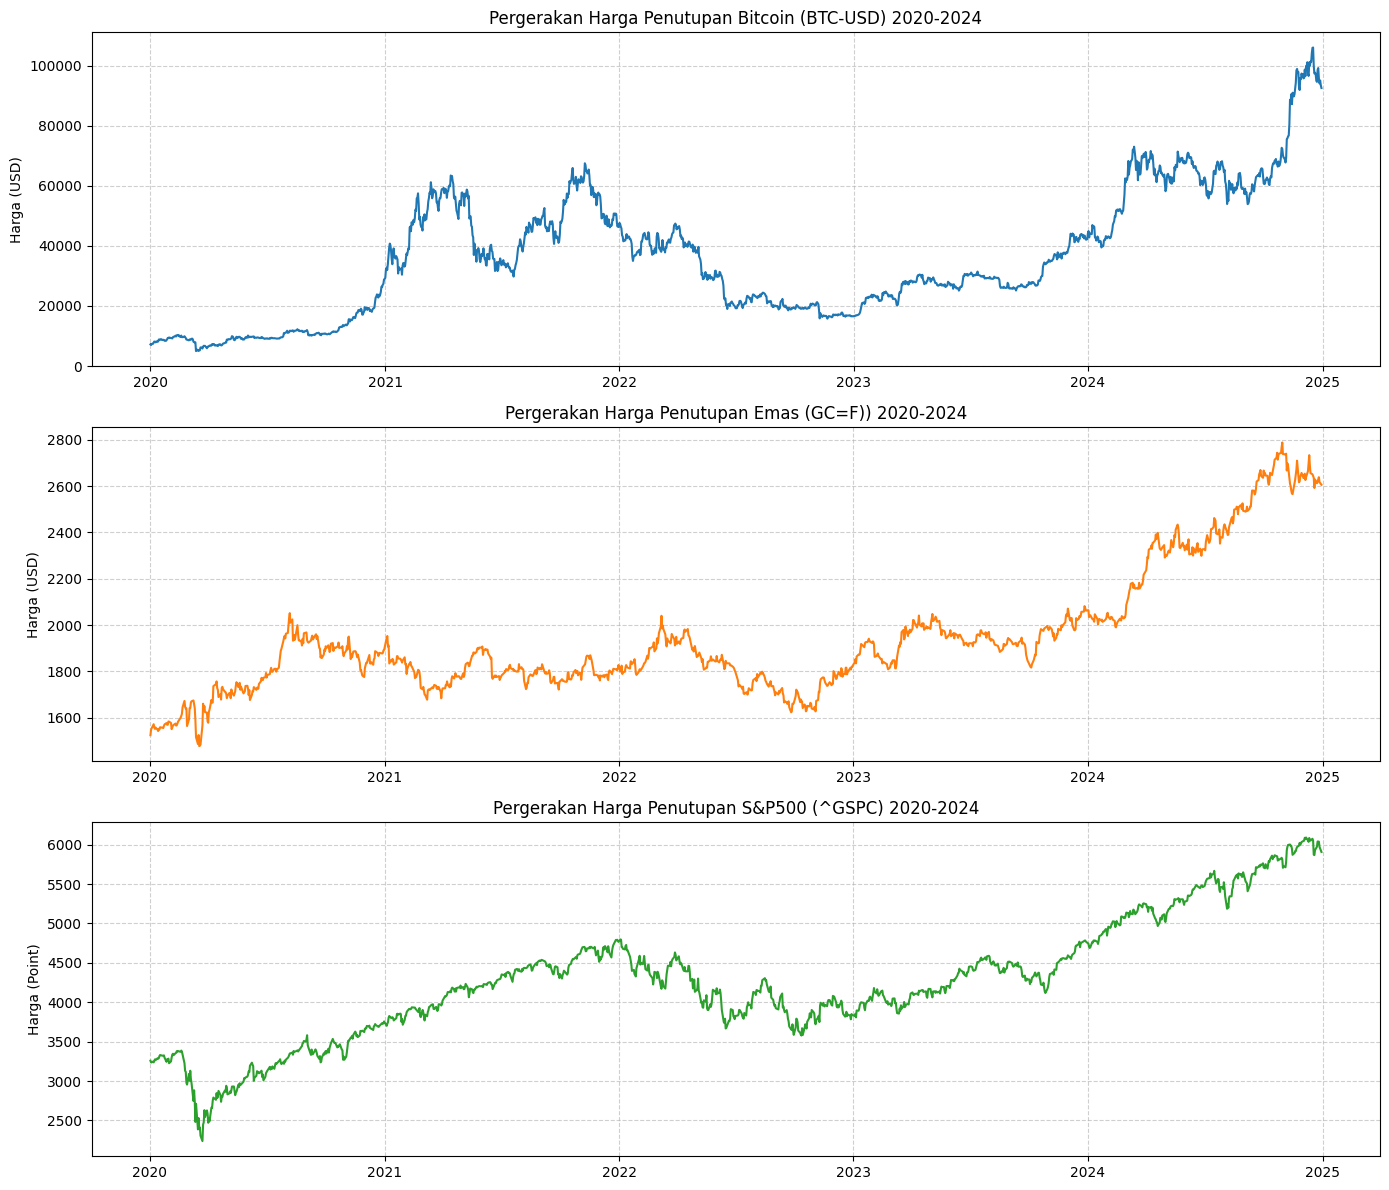

In [ ]:
# Visualisasi Grafik Harga Penutupan
plt.figure(figsize = (14, 12))

plt.subplot(3, 1, 1)
plt.plot(btc_df.index, btc_df['Close'], color = 'tab:blue')
plt.title('Pergerakan Harga Penutupan Bitcoin (BTC-USD) 2020-2024', fontsize = 12)
plt.ylabel('Harga (USD)', fontsize = 10)
plt.grid(True, linestyle = '--', alpha = 0.6)

plt.subplot(3, 1, 2)
plt.plot(gold_df.index, gold_df['Close'], color = 'tab:orange')
plt.title('Pergerakan Harga Penutupan Emas (GC=F)) 2020-2024', fontsize = 12)
plt.ylabel('Harga (USD)', fontsize = 10)
plt.grid(True, linestyle = '--', alpha = 0.6)

plt.subplot(3, 1, 3)
plt.plot(sp500_df.index, sp500_df['Close'], color = 'tab:green')
plt.title('Pergerakan Harga Penutupan S&P500 (^GSPC) 2020-2024', fontsize = 12)
plt.ylabel('Harga (Point)', fontsize = 10)
plt.grid(True, linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

# 2. Prapemrosesan Data

## 2.1 Pembersihan Data

In [ ]:
df_merged = pd.DataFrame({
    'BTC': btc_df[('Close', 'BTC-USD')],
    'Gold': gold_df[('Close', 'GC=F')],
    'S&P500': sp500_df[('Close', '^GSPC')]
})

print("--- Kondisi Sebelum Data Dibersihkan ---")
print(df_merged.head())
print("\n Jumlah Missing Values:")
print(df_merged.isnull().sum())

# Forward Fill
df_clean = df_merged.ffill()

# Barckward Fill Hari Pertama
df_clean = df_clean.bfill()

print("\n--- Kondisi Setelah Data Dibersihkan ---")
print(df_clean.head())
print("\n Jumlah Missing Values:")
print(df_clean.isnull().sum())

--- Kondisi Sebelum Data Dibersihkan ---
                    BTC         Gold       S&P500
Date                                             
2020-01-01  7200.174316          NaN          NaN
2020-01-02  6985.470215  1524.500000  3257.850098
2020-01-03  7344.884277  1549.199951  3234.850098
2020-01-04  7410.656738          NaN          NaN
2020-01-05  7411.317383          NaN          NaN

 Jumlah Missing Values:
BTC         0
Gold      569
S&P500    569
dtype: int64

--- Kondisi Setelah Data Dibersihkan ---
                    BTC         Gold       S&P500
Date                                             
2020-01-01  7200.174316  1524.500000  3257.850098
2020-01-02  6985.470215  1524.500000  3257.850098
2020-01-03  7344.884277  1549.199951  3234.850098
2020-01-04  7410.656738  1549.199951  3234.850098
2020-01-05  7411.317383  1549.199951  3234.850098

 Jumlah Missing Values:
BTC       0
Gold      0
S&P500    0
dtype: int64


In [ ]:
# === Feature Engineering: Transformasi Log Return ===
# BTC tetap raw close price (TARGET prediksi)
# Gold dan S&P500 diubah ke log return agar stasioner dan skala comparable

print("--- Transformasi Log Return ---")
print(f"Sebelum transformasi: {len(df_clean)} baris")

df_clean['Gold'] = np.log(df_clean['Gold'] / df_clean['Gold'].shift(1))
df_clean['S&P500'] = np.log(df_clean['S&P500'] / df_clean['S&P500'].shift(1))

# Drop baris pertama yang NaN akibat shift(1)
df_clean = df_clean.dropna()

print(f"Setelah transformasi: {len(df_clean)} baris")
print(f"\nKolom: {list(df_clean.columns)}")
print(f"\n5 Baris Pertama Setelah Transformasi:")
print(df_clean.head())
print(f"\nStatistik Deskriptif:")
print(df_clean.describe())

--- Transformasi Log Return ---
Sebelum transformasi: 1826 baris
Setelah transformasi: 1825 baris

Kolom: ['BTC', 'Gold', 'S&P500']

5 Baris Pertama Setelah Transformasi:
                    BTC      Gold    S&P500
Date                                       
2020-01-02  6985.470215  0.000000  0.000000
2020-01-03  7344.884277  0.016072 -0.007085
2020-01-04  7410.656738  0.000000  0.000000
2020-01-05  7411.317383  0.000000  0.000000
2020-01-06  7769.219238  0.010914  0.003527

Statistik Deskriptif:
                 BTC         Gold       S&P500
count    1825.000000  1825.000000  1825.000000
mean    36302.022015     0.000294     0.000326
std     21077.989056     0.008512     0.011204
min      4970.788086    -0.051069    -0.127652
25%     19623.580078    -0.001713    -0.001956
50%     32186.277344     0.000000     0.000000
75%     50700.085938     0.003680     0.003777
max    106140.601562     0.057775     0.089683


## 2.2 Pembagian Data

In [ ]:
print("--- Memulai Pembagian Dataset ---")

# Data Latih: 1 Januari 2020 - 31 Desember 2023
train_data = df_clean.loc['2020-01-01':'2023-12-31']

# Data Uji: 1 Januari 2024 - 31 Desember 2024
test_data = df_clean.loc['2024-01-01':'2024-12-31']

print(f"Jumlah baris data latih (2020-2023): {len(train_data)} hari")
print(f"Jumlah baris data uji (2024): {len(test_data)} hari")

--- Memulai Pembagian Dataset ---
Jumlah baris data latih (2020-2023): 1460 hari
Jumlah baris data uji (2024): 365 hari


## 2.3 Normalisasi Data

In [ ]:
  print("\n--- Memulai Normalisasi Data ---")

  scaler = MinMaxScaler(feature_range=(0, 1))

  train_scaled_array = scaler.fit_transform(train_data)

  test_scaled_array = scaler.transform(test_data)

  train_scaled_df = pd.DataFrame(train_scaled_array, columns = train_data.columns, index = train_data.index)
  test_scaled_df = pd.DataFrame(test_scaled_array, columns = test_data.columns, index = test_data.index)

  print("\n 5 Baris Pertama Data Latih Setelah Normalisasi:")
  print(train_scaled_df.head())


--- Memulai Normalisasi Data ---

 5 Baris Pertama Data Latih Setelah Normalisasi:
                 BTC      Gold    S&P500
Date                                    
2020-01-02  0.032185  0.469196  0.587351
2020-01-03  0.037927  0.616858  0.554752
2020-01-04  0.038978  0.469196  0.587351
2020-01-05  0.038989  0.469196  0.587351
2020-01-06  0.044706  0.569464  0.603580


## 2.4 Pembentukan Jendela Data

In [ ]:
def create_sliding_window(data, window_size, target_index):
    X, y = [], []

    for i in range(len(data) - window_size):
        window_X = data[i : i + window_size, :]
        X.append(window_X)

        target_y = data[i + window_size, target_index]
        y.append(target_y)

    return np.array(X), np.array(y)

# Eksekusi Windowing
print("--- Memulai Pembentukan Jendela Data ---")

ukuran_jendela = 7
indeks_target = 0

X_train, y_train = create_sliding_window(train_scaled_array, ukuran_jendela, indeks_target)

X_test, y_test = create_sliding_window(test_scaled_array, ukuran_jendela, indeks_target)

print("\n--- Pengecekan Dimensi (Shape) Data Akhir ---")
print(f"Bentuk X_train : {X_train.shape} -> (Jumlah Sampel, Time Steps, Fitur)")
print(f"Bentuk y_train : {y_train.shape} -> (Jumlah Sampel, Target Prediksi)")
print(f"Bentuk X_test : {X_test.shape} -> (Jumlah Sampel, Time Steps, Fitur)")
print(f"Bentuk y_test : {y_test.shape} -> (Jumlah Sampel, Target Prediksi)")

--- Memulai Pembentukan Jendela Data ---

--- Pengecekan Dimensi (Shape) Data Akhir ---
Bentuk X_train : (1453, 7, 3) -> (Jumlah Sampel, Time Steps, Fitur)
Bentuk y_train : (1453,) -> (Jumlah Sampel, Target Prediksi)
Bentuk X_test : (358, 7, 3) -> (Jumlah Sampel, Time Steps, Fitur)
Bentuk y_test : (358,) -> (Jumlah Sampel, Target Prediksi)


# 3 Pembangunan Model

## 3.1 Pembangunan Arsitektur

In [ ]:
# Fungsi Pembangun Model
def build_model(hp):
    model = Sequential()

    # Lapisan 1D-CNN (Ekstraksi Fitur)
    # CNN Filters (32, 64, 128), Kernel Size (2, 3, 5), Activation (ReLU, Tanh)
    hp_filters = hp.Choice('cnn_filters', values = [32, 64, 128])
    hp_kernel_size = hp.Choice('kernel_size', values = [2, 3, 5])
    hp_activation = hp.Choice('activation', values = ['relu', 'tanh'])

    # input_shape=(7, 3) karena kita punya lookback 7 hari dan 3 fitur (BTC, Gold, SP500)
    model.add(Conv1D(
        filters = hp_filters,
        kernel_size = hp_kernel_size,
        activation = hp_activation,
        input_shape = (7,3)
        ))

    # Lapisan Pooling (Reduksi Dimensi Spasial)
    # Pooling Size = 2 (Nilai tetap, bukan untuk dituning)
    model.add(MaxPooling1D(pool_size = 2))

    # Lapisan LSTM (Menangkap Ketergantungan Jangka Panjang)
    # LSTM Units (50, 100, 200)
    hp_lstm_units = hp.Choice('lstm_units', values = [50, 100, 200])
    model.add(LSTM(units = hp_lstm_units))

    # Lapisan Dropout (Regulerisasi Untuk Mencegah Overfitting)
    # Dropout (0.2, 0.3, 0.5)
    hp_dropout = hp.Choice('dropout', values = [0.2, 0.3, 0.5])
    model.add(Dropout(rate = hp_dropout))

    # Lapisan Output (Dense)
    # Menggunakan 1 neuron karena kita memprediksi 1 nilai kontinu (harga penutupan BTC keesokan harinya)
    model.add(Dense(units = 1))

    # Penyetalan Optimizer dan Learning Rate
    # Optimizer (Adam, RMSprop), Learning Rate (0.01, 0.001, 0.0001)
    hp_optimizer = hp.Choice('optimizer', values = ['adam', 'rmsprop'])
    hp_learning_rate = hp.Choice('learning_rate', values = [0.01, 0.001, 0.0001])

    if hp_optimizer == 'adam':
        optimizer = Adam(learning_rate = hp_learning_rate)
    else:
        optimizer = RMSprop(learning_rate = hp_learning_rate)

    # Kompilasi Model
    # Mean Squared Error (MSE) sebagia loss function utama saat pelatihan
    model.compile(optimizer = optimizer, loss = 'mse', metrics = ['mae'])

    return model

print("Fungsi build_model berhasil didefinisikan!")

Fungsi build_model berhasil didefinisikan!


## 3.2 Pencarian Parameter Terbaik

In [ ]:
# print("--- Inisialisasi Pencarian Grid ---")

# tuner = kt.GridSearch(
#     hypermodel = build_model,
#     objective = 'val_loss',
#     max_trials = 50,
#     seed = 42,
#     directory = 'hasil_tuning_cnn_lstm',
#     project_name = 'skripsi_bitcoin_multivariat'
# )

# tuner.search_space_summary()

# print("\n--- Memulai Proses Pencarian (Tuning) ---")

# # Menerapkan Early Stopping
# # Jika val_loss tidak membaik setelah 10 epoch berturut-turut, hentikan pelatihan
# early_stop = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# # menggunakan epochs = 100  dan batch_size = 32 sebagai baseline
# tuner.search(
#     x = X_train,
#     y = y_train,
#     epochs = 100,
#     batch_size = 32,
#     validation_split = 0.2, # Menyisihkan 20% dari data latih secara internal untuk validasi
#     callbacks = [early_stop],
#     verbose = 1
# )

# print("\n--- Pencarian Selesai! Mengekstrak Hiperparameter Terbaik ---")

# best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

# print(f"""
# Konfigurasi Arsitektur CNN-LSTM Paling Optimal:
# - CNN Filters           : {best_hps.get('cnn_filters')}
# - Kernel Size           : {best_hps.get('kernel_size')}
# - Activation Function   : {best_hps.get('activation')}
# - LSTM Units            : {best_hps.get('lstm_units')}
# - Dropout Rate          : {best_hps.get('dropout')}
# - Optimizer             : {best_hps.get('optimizer')}
# - Learning Rate         : {best_hps.get('learning_rate')}
# """)

# best_model = tuner.hypermodel.build(best_hps)

# best_model.summary()

In [ ]:
# print("--- Inisialisasi Pencarian Intensif (Bayesian Optimization) ---")

# tuner = kt.BayesianOptimization(
#     hypermodel = build_model,
#     objective = 'val_loss',
#     max_trials = 150,
#     num_initial_points = 20,
#     seed = 42,
#     directory = 'hasil_tuning_intensif',
#     project_name = 'cnn_lstm_bitcoin_bayesian'
# )

# tuner.search_space_summary()

# print("\n--- Memulai Proses Pencarian (Tuning) ---")

# # Menerapkan Early Stopping
# # Jika val_loss tidak membaik setelah 10 epoch berturut-turut, hentikan pelatihan
# early_stop = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# # menggunakan epochs = 100  dan batch_size = 32 sebagai baseline
# tuner.search(
#     x = X_train,
#     y = y_train,
#     epochs = 100,
#     batch_size = 32,
#     validation_split = 0.2, # Menyisihkan 20% dari data latih secara internal untuk validasi
#     callbacks = [early_stop],
#     verbose = 1
# )

# print("\n--- Pencarian Selesai! Mengekstrak Hiperparameter Terbaik ---")

# best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]

# print(f"""
# Konfigurasi Arsitektur CNN-LSTM Paling Optimal:
# - CNN Filters           : {best_hps.get('cnn_filters')}
# - Kernel Size           : {best_hps.get('kernel_size')}
# - Activation Function   : {best_hps.get('activation')}
# - LSTM Units            : {best_hps.get('lstm_units')}
# - Dropout Rate          : {best_hps.get('dropout')}
# - Optimizer             : {best_hps.get('optimizer')}
# - Learning Rate         : {best_hps.get('learning_rate')}
# """)

# best_model = tuner.hypermodel.build(best_hps)

# best_model.summary()

# 4 Perancangan Skenario Eksperimen

In [ ]:
def build_optimal_model(num_features):
    model = Sequential()

    # Layer CNN
    model.add(Conv1D(filters = 32, kernel_size = 2, activation = 'tanh', input_shape = (7, num_features)))
    model.add(MaxPooling1D(pool_size = 2))

    # Layer LSTM
    model.add(LSTM(units = 50))

    # Layer Dropout
    model.add(Dropout(rate = 0.2))

    # Layer Output
    model.add(Dense(units = 1))

    # Kompilasi
    optimizer = Adam(learning_rate = 0.01)
    model.compile(optimizer = optimizer, loss = 'mse')

    return model

# Definisi Skenario Eksperimen
# Indeks fitur berdasarkan df_merged: 0 (BTC), 1 (Gold), 2 (S&P500)
skenario_dict = {
    "Skenario A (Model Lengkap)": [0, 1, 2],
    "Skenario B (Ablasi Emas)": [0, 2],
    "Skenario C (Ablasi S&P500)": [0, 1],
    "Skenario D (Univariat)": [0]
}

# 5 Pelatihan dan Evaluasi Model

--- Memulai Eksekusi Skenario Eksperimen ---

 Melatih Skenario A (Model Lengkap) (Jumlah Fitur: 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Selesai! RMSE: 3130.68 | MAPE: 2.98%

 Melatih Skenario B (Ablasi Emas) (Jumlah Fitur: 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Selesai! RMSE: 3595.04 | MAPE: 3.35%

 Melatih Skenario C (Ablasi S&P500) (Jumlah Fitur: 2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Selesai! RMSE: 2411.03 | MAPE: 2.56%

 Melatih Skenario D (Univariat) (Jumlah Fitur: 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Selesai! RMSE: 2532.41 | MAPE: 2.61%

KESIMPULAN HASIL EKSPERIMEN (STUDI ABLASI)

                  Skenario  RMSE (USD)  MAPE (%)
Skenario A (Model Lengkap) 3130.675812  2.980390
  Skenario B (Ablasi Emas) 3595.043169  3.348080
Skenario C (Ablasi S&P500) 2411.030546  2.557491
    Skenario D (Univariat) 2532.408278  2.608137


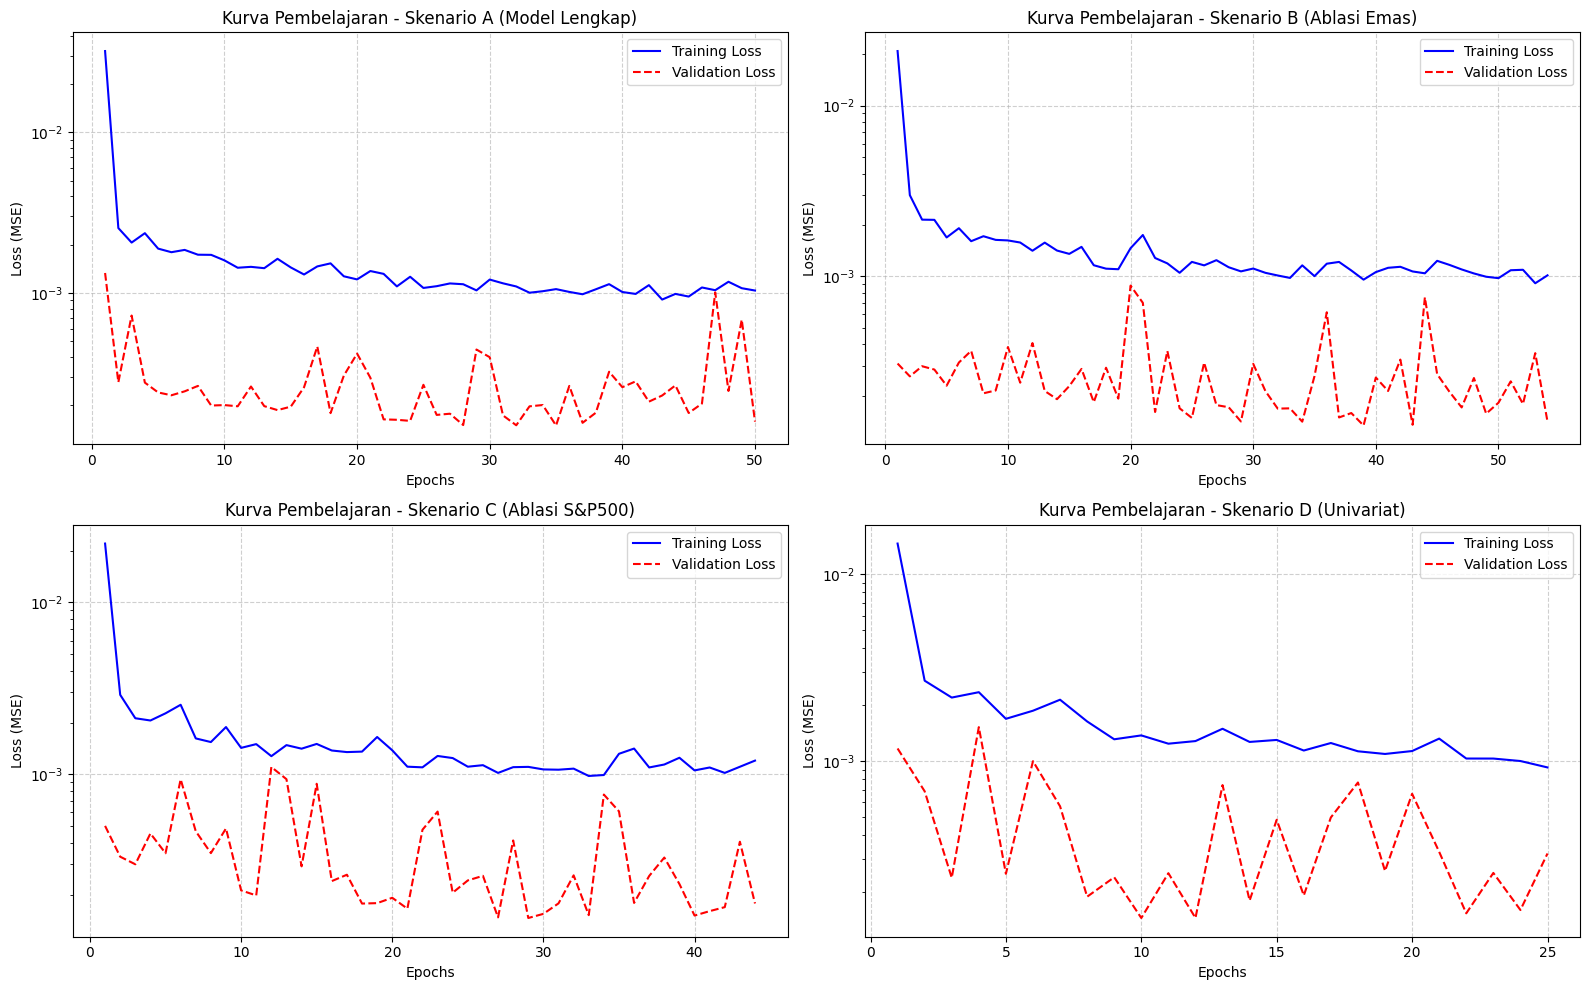

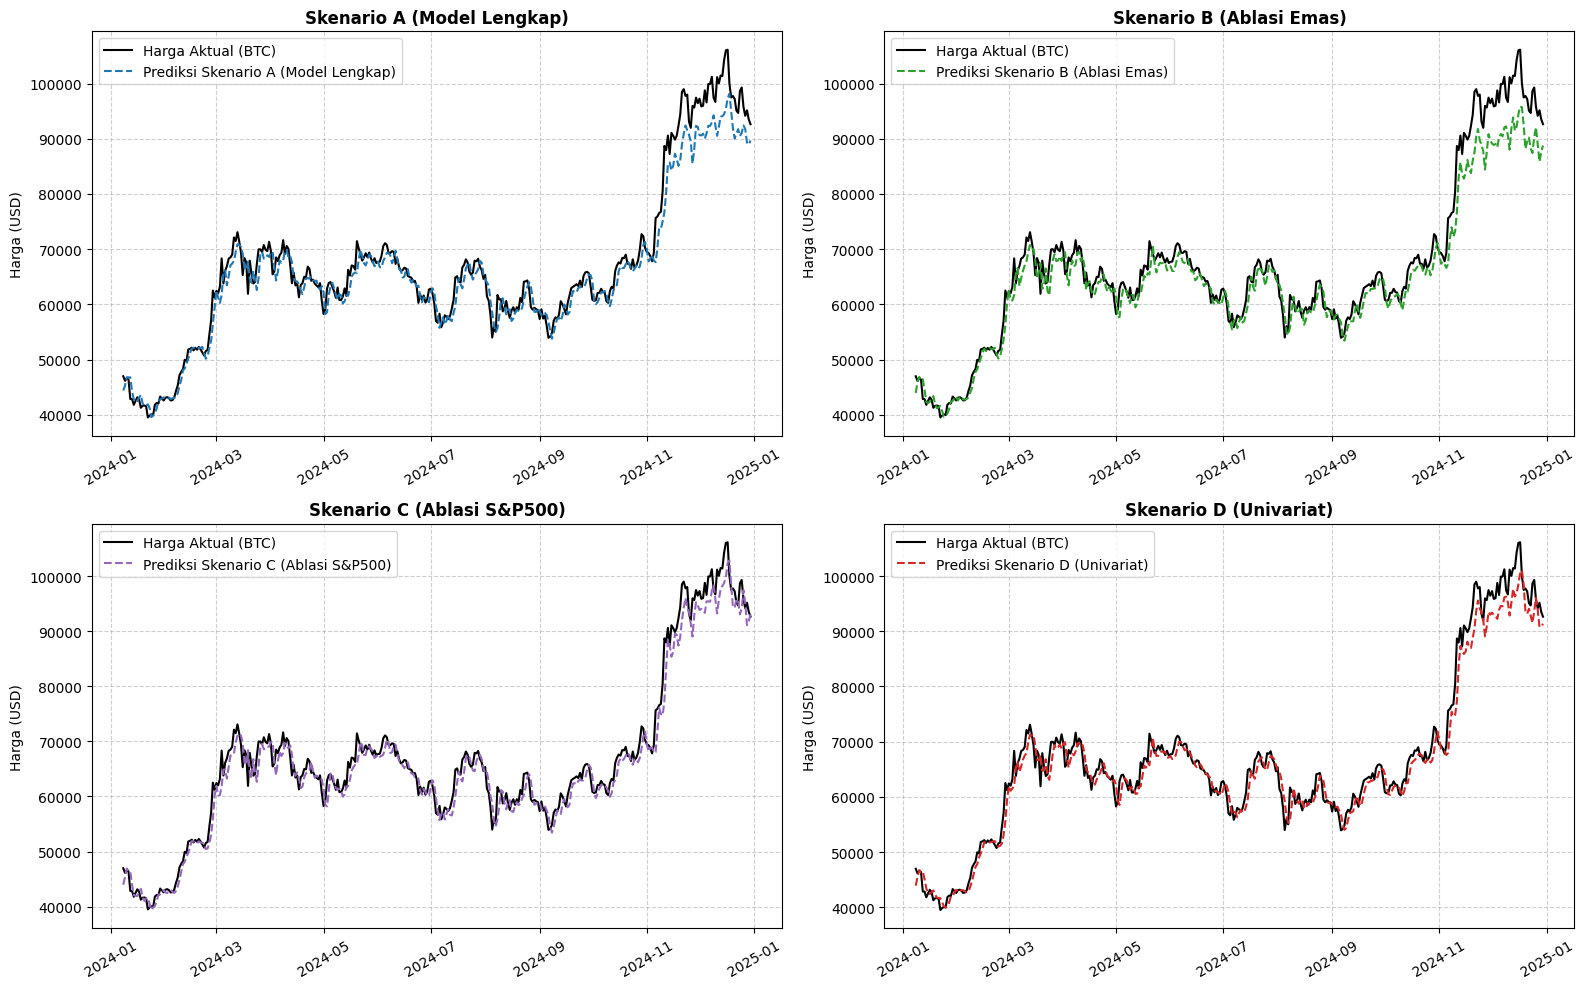

In [ ]:
print("--- Memulai Eksekusi Skenario Eksperimen ---")

# Fungsi Inverse Transform khusus target (BTC)
def inverse_transform_target(prediksi, scaler):
    # Array dummy karena scaler sebelumnya dilatih pada 3 fitur
    dummy_array = np.zeros((len(prediksi), 3))
    dummy_array[:, 0] = prediksi.flatten()
    return scaler.inverse_transform(dummy_array)[:, 0]

# Siapkan target aktual (y_test) ke dalam nilai Dollar
y_test_asli = inverse_transform_target(y_test, scaler)

#Menyimpan Hasil Evaluasi
hasil_evaluasi = []
prediksi_dict = {}
history_dict = {} # Menyimpan history error tiap epoch
model_tersimpan = {}

# Iterasi Semua Skenario
for nama_skenario, indeks_fitur in skenario_dict.items():
    print(f"\n Melatih {nama_skenario} (Jumlah Fitur: {len(indeks_fitur)})")

    # a. Memotong dataset sesuai skenario
    X_train_skenario = X_train[:, :, indeks_fitur]
    X_test_skenario = X_test[:, :, indeks_fitur]

    # b. Membangun Model
    model = build_optimal_model(num_features = len(indeks_fitur))

    # c. Melatih Model
    early_stop = EarlyStopping(monitor = 'val_loss', patience = 15, restore_best_weights = True)
    history = model.fit(
        X_train_skenario, y_train,
        epochs = 100,
        batch_size = 32,
        validation_split = 0.2,
        callbacks = [early_stop],
        verbose = 0
    )

    history_dict[nama_skenario] = history.history
    model_tersimpan[nama_skenario] = model

    # d. Prediksi Data Uji
    y_pred_scaled = model.predict(X_test_skenario)

    # e. Mengembalikan prediksi ke nilai Dollar asli (Inverse Transform)
    y_pred_asli = inverse_transform_target(y_pred_scaled, scaler)

    # f. Menghitung metrik RMSE dan MAPE
    rmse = root_mean_squared_error(y_test_asli, y_pred_asli)
    # MAPE dalam bentuk persentase
    mape = mean_absolute_percentage_error(y_test_asli, y_pred_asli) * 100

    # Menyimpan hasil prediksi
    prediksi_dict[nama_skenario] = y_pred_asli

    # Menyimpan Hasil
    hasil_evaluasi.append({
        "Skenario": nama_skenario,
        "RMSE (USD)": rmse,
        "MAPE (%)": mape
    })
    print(f"Selesai! RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")

# HASIL AKHIR
print("\n=======================================================")
print("KESIMPULAN HASIL EKSPERIMEN (STUDI ABLASI)")
print("\n=======================================================")

df_hasil = pd.DataFrame(hasil_evaluasi)
print(df_hasil.to_string(index = False))

# Visualisasi Loss Graph
fig_loss, axes_loss = plt.subplots(nrows = 2, ncols = 2, figsize = (16, 10))
axes_loss = axes_loss.flatten()

for i, (nama_skenario, hist) in enumerate(history_dict.items()):
    loss = hist['loss']
    val_loss = hist['val_loss']
    epochs = range(1, len(loss) + 1)

    axes_loss[i].plot(epochs, loss, 'b-', label = 'Training Loss')
    axes_loss[i].plot(epochs, val_loss, 'r--', label = 'Validation Loss')

    axes_loss[i].set_title(f'Kurva Pembelajaran - {nama_skenario}')
    axes_loss[i].set_xlabel('Epochs')
    axes_loss[i].set_ylabel('Loss (MSE)')
    axes_loss[i].set_yscale('log')
    axes_loss[i].legend()
    axes_loss[i].grid(True, linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

# Mengambil indeks tanggal untuk sumbu X
# Dimulai dari hari ke-7 karena memakai lookback window ukuran 7
tanggal_uji = test_data.index[ukuran_jendela:]

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (16, 10))
axes = axes.flatten()

warna_garis = ['tab:blue', 'tab:green', 'tab:purple', 'tab:red']

# Visualisasi
for i, (nama_skenario, y_pred) in enumerate(prediksi_dict.items()):
    # Harga aktual (hitam solid)
    axes[i].plot(tanggal_uji, y_test_asli, label = 'Harga Aktual (BTC)', color = 'black')

    # Harga prediksi (putus berwarna)
    axes[i].plot(tanggal_uji, y_pred, label = f'Prediksi {nama_skenario}', color = warna_garis[i], linestyle = '--')

    axes[i].set_title(f'{nama_skenario}', fontsize = 12, fontweight = 'bold')
    axes[i].set_ylabel('Harga (USD)', fontsize = 10)
    axes[i].legend(loc = 'upper left')
    axes[i].grid(True, linestyle = '--', alpha = 0.6)

    axes[i].tick_params(axis = 'x', rotation = 30)

plt.tight_layout()
plt.show()


--- Memulai Forecasting 14 Hari ke Depan untuk SEMUA Skenario ---
Memproses peramalan untuk Skenario A (Model Lengkap)...
Memproses peramalan untuk Skenario B (Ablasi Emas)...
Memproses peramalan untuk Skenario C (Ablasi S&P500)...
Memproses peramalan untuk Skenario D (Univariat)...

Semua peramalan selesai! Menyiapkan visualisasi...


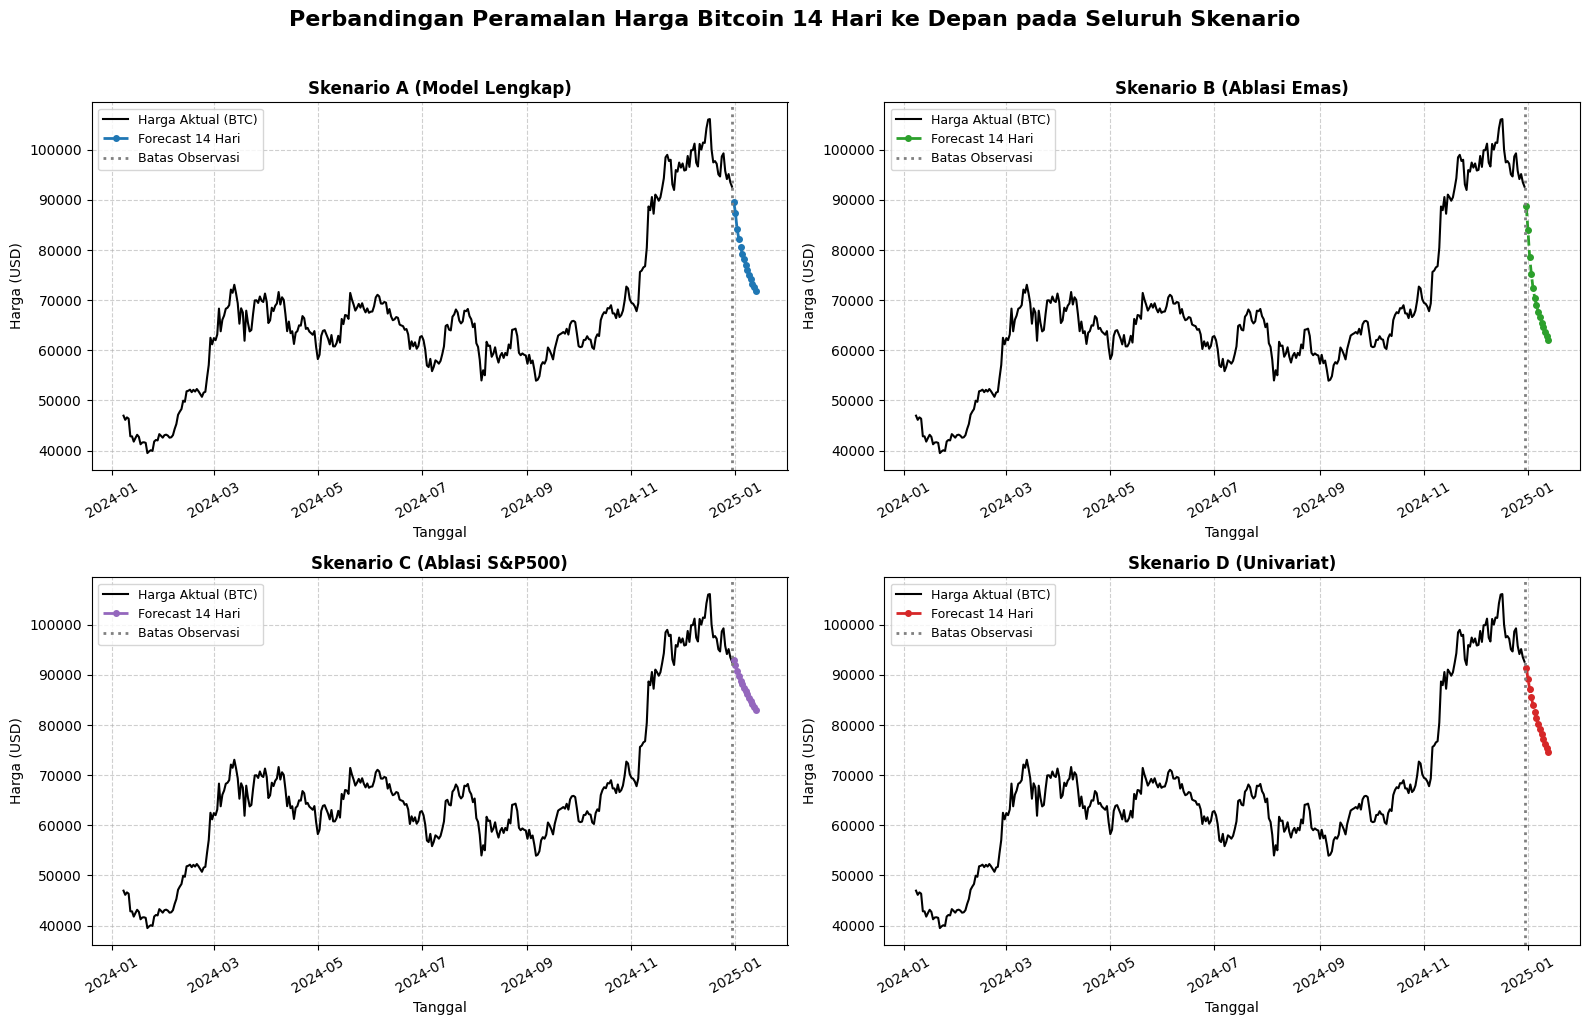

In [ ]:
print("\n--- Memulai Forecasting 14 Hari ke Depan untuk SEMUA Skenario ---")

hari_forecast = 14
ukuran_jendela = 7

# Dictionary baru untuk menyimpan hasil prediksi dari masing-masing skenario
forecast_dict = {}

# 1. Melakukan Looping untuk setiap model yang tersimpan di memori
for nama_skenario, model_skenario in model_tersimpan.items():
    print(f"Memproses peramalan untuk {nama_skenario}...")

    # Ambil indeks fitur khusus untuk skenario yang sedang dilooping
    indeks_fitur = skenario_dict[nama_skenario]
    X_test_skenario = X_test[:, :, indeks_fitur]

    # Ambil observasi terakhir dari data uji
    last_window = X_test_skenario[-1].copy()
    hasil_forecast_scaled = []

    # Looping peramalan 14 hari rekursif
    for i in range(hari_forecast):
        # Reshape input secara dinamis sesuai jumlah fitur pada skenario ini
        current_input = last_window.reshape(1, ukuran_jendela, len(indeks_fitur))

        # Prediksi harga BTC untuk hari besok (skala 0-1)
        pred_scaled = model_skenario.predict(current_input, verbose=0)[0][0]
        hasil_forecast_scaled.append(pred_scaled)

        # Buat baris baru
        new_row = np.zeros(len(indeks_fitur))
        new_row[0] = pred_scaled  # Target prediksi BTC

        # Asumsi Naif: Salin nilai eksogen HANYA JIKA skenario punya lebih dari 1 fitur
        # (Ini mencegah error pada Skenario D / Univariat yang hanya punya 1 fitur)
        if len(indeks_fitur) > 1:
            new_row[1:] = last_window[-1, 1:]

        # Geser Sliding Window (buang hari terlama, masukkan hari baru)
        last_window = np.vstack((last_window[1:], new_row))

    # Kembalikan prediksi ke nominal Dollar (USD)
    hasil_forecast_scaled = np.array(hasil_forecast_scaled).reshape(-1, 1)
    forecast_usd = inverse_transform_target(hasil_forecast_scaled, scaler)

    # Simpan hasil forecast ke dalam dictionary
    forecast_dict[nama_skenario] = forecast_usd

print("\nSemua peramalan selesai! Menyiapkan visualisasi...")

# --- Visualisasi Hasil Forecast (Grid 2x2) ---
# Siapkan deret tanggal untuk masa lalu dan masa depan
tanggal_terakhir = test_data.index[-1]
tanggal_forecast = pd.date_range(start=tanggal_terakhir + pd.Timedelta(days=1), periods=hari_forecast)
tanggal_uji = test_data.index[ukuran_jendela:]

# Siapkan kanvas matriks berukuran 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

# Palet warna garis untuk membedakan tiap skenario
warna_garis = ['tab:blue', 'tab:green', 'tab:purple', 'tab:red']

# Looping untuk menggambar grafik tiap skenario
for i, (nama_skenario, forecast_usd) in enumerate(forecast_dict.items()):

    # 1. Gambar KESELURUHAN data aktual pada set pengujian (Garis Hitam Solid)
    axes[i].plot(tanggal_uji, y_test_asli, label='Harga Aktual (BTC)', color='black', linewidth=1.5)

    # 2. Gambar garis prediksi 14 hari ke masa depan (Garis Berwarna Putus-putus)
    axes[i].plot(tanggal_forecast, forecast_usd,
                 label='Forecast 14 Hari',
                 color=warna_garis[i], linestyle='--', marker='o', markersize=4, linewidth=2)

    # 3. Garis vertikal pemisah antara masa lalu dan masa depan
    axes[i].axvline(x=tanggal_uji[-1], color='gray', linestyle=':', linewidth=2, label='Batas Observasi')

    # Mempercantik tampilan masing-masing subplot
    axes[i].set_title(f'{nama_skenario}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Tanggal', fontsize=10)
    axes[i].set_ylabel('Harga (USD)', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(loc='upper left', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30)

# Menambahkan judul utama di atas keseluruhan grafik
fig.suptitle('Perbandingan Peramalan Harga Bitcoin 14 Hari ke Depan pada Seluruh Skenario', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# Visualisasi Hasil Forecast pada matriks 2x2
for i, (nama_skenario, forecast_usd) in enumerate(forecast_dict.items()):
    # Gambar garis data aktual masa lalu (Hitam)
    axes[i].plot(tanggal_uji, y_test_asli, label='Harga Aktual (BTC)', color='black')

    # Gambar garis prediksi masa depan (Berwarna & Putus-putus)
    axes[i].plot(tanggal_forecast, forecast_usd, label='Forecast 14 Hari',
                 color=warna_garis[i], linestyle='--', marker='o')

    # Buat garis vertikal pemisah
    axes[i].axvline(x=tanggal_uji[-1], color='gray', linestyle=':', label='Batas Observasi')